# Exploratory Data Analysis (EDA) — DNS Tunneling Detection

Analyze feature distributions, class balance, correlations, and patterns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Combined Data

In [3]:
df = pd.read_csv('../data/combined_dns_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())

Dataset shape: (1167269, 36)

First few rows:
         SourceIP   DestinationIP  SourcePort  DestinationPort  \
0     72.21.91.42  192.168.20.191         443            51041   
1  192.168.20.191  195.201.169.48       51043              443   
2  192.168.20.191    96.17.115.57       51021              443   
3  192.168.20.191   96.114.14.140       50308              443   
4  192.168.20.191   23.78.199.198       50983              443   

             TimeStamp  Duration  FlowBytesSent  FlowSentRate  \
0  2020-01-14 15:49:01  4.544040       11256331  2.477164e+06   
1  2020-01-14 15:49:03  8.171041            930  1.138166e+02   
2  2020-01-14 15:49:03  0.033776            162  4.796305e+03   
3  2020-01-14 15:49:03  0.060723            108  1.778568e+03   
4  2020-01-14 15:49:03  0.019545             55  2.814019e+03   

   FlowBytesReceived  FlowReceivedRate  ...  ResponseTimeTimeVariance  \
0             159324      35062.191354  ...              1.107852e-07   
1              11936

In [4]:
df.columns

Index(['SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort',
       'TimeStamp', 'Duration', 'FlowBytesSent', 'FlowSentRate',
       'FlowBytesReceived', 'FlowReceivedRate', 'PacketLengthVariance',
       'PacketLengthStandardDeviation', 'PacketLengthMean',
       'PacketLengthMedian', 'PacketLengthMode', 'PacketLengthSkewFromMedian',
       'PacketLengthSkewFromMode', 'PacketLengthCoefficientofVariation',
       'PacketTimeVariance', 'PacketTimeStandardDeviation', 'PacketTimeMean',
       'PacketTimeMedian', 'PacketTimeMode', 'PacketTimeSkewFromMedian',
       'PacketTimeSkewFromMode', 'PacketTimeCoefficientofVariation',
       'ResponseTimeTimeVariance', 'ResponseTimeTimeStandardDeviation',
       'ResponseTimeTimeMean', 'ResponseTimeTimeMedian',
       'ResponseTimeTimeMode', 'ResponseTimeTimeSkewFromMedian',
       'ResponseTimeTimeSkewFromMode',
       'ResponseTimeTimeCoefficientofVariation', 'DoH', 'Label'],
      dtype='object')

features explanation:
- **TimeStamp**: The time when the DNS query was made (2020-01-14 15:49:01)
- **duration**: The duration of the DNS query (0.0 seconds)
- **flowBytesSent**: The number of bytes sent in the DNS query (0 bytes)
- **flowBytesReceived**: The number of bytes received in the DNS query (0 bytes)
- **flowSentRate**: The rate at which bytes are sent in the DNS query (0.0)
- **flowReceivedRate**: The rate at which bytes are received in the DNS query (0.0)
- **packetLengthMean**: The mean length of packets in the DNS query (0.0 bytes)
- **packetLengthStd**: The standard deviation of packet lengths in the DNS query (0.0 bytes)
- **packetLengthVariance**: The variance of packet lengths in the DNS query (0.0 bytes)
- **packetLengthMedian**: The median length of packets in the DNS query (0 bytes)
- **packetLengthMode**: The mode of packet lengths in the DNS query (0 bytes)
- **packetLengthSkewFromMedian**: The skewness of packet lengths from the median in the DNS query (0.0)
- **packetLengthSkewFromMode**: The skewness of packet lengths from the mode in the DNS query (0.0)
- **PacketTimeCoefficientofVariation**: The coefficient of variation of packet times in the DNS query 
- **ResponseTimeTimeVariance**: The variance of response times in the DNS query (0.0)
- **ResponseTimeTimeStandardDeviation**: The standard deviation of response times in the DNS query (0.0)
- **ResponseTimeTimeMean**: The mean of response times in the DNS query (0.0)
- **ResponseTimeTimeMedian**: The median of response times in the DNS query (0.0)
- **ResponseTimeTimeMode**: The mode of response times in the DNS query (0.0)
- **ResponseTimeTimeSkewFromMedian**: The skewness of response times from the median in the DNS query 
- **ResponseTimeTimeSkewFromMode**: The skewness of response times from the mode in the DNS query (0.0)
- **ResponseTimeTimeCoefficientofVariation**: The coefficient of variation of response times in the DNS query (0.0)
- **DoH**: A binary indicator for DoH traffic (0 or 1) (DOH is a protocol for performing remote Domain Name System (DNS) resolution via the HTTPS protocol. It is designed to increase user privacy and security by preventing eavesdropping and manipulation of DNS data by third parties.)
- **Label**: The label for the DNS query (e.g., benign or malicious)

## 2. Class Balance Analysis

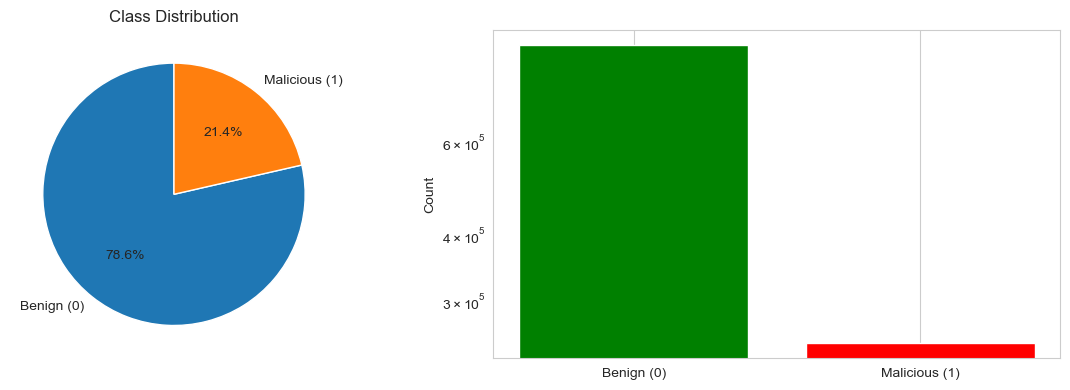

Benign: 917,300 (78.59%)
Malicious: 249,969 (21.41%)


In [5]:
class_counts = df['Label'].value_counts()
class_names = ['Benign (0)', 'Malicious (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(class_counts.values, labels=class_names, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Class Distribution')
axes[1].bar(class_names, class_counts.values, color=['green', 'red'])
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

for label, count in class_counts.items():
    pct = (count / len(df)) * 100
    print(f'{"Benign" if label == 0 else "Malicious"}: {count:,} ({pct:.2f}%)')

## 3. Feature Distributions by Class

Total numeric features: 31


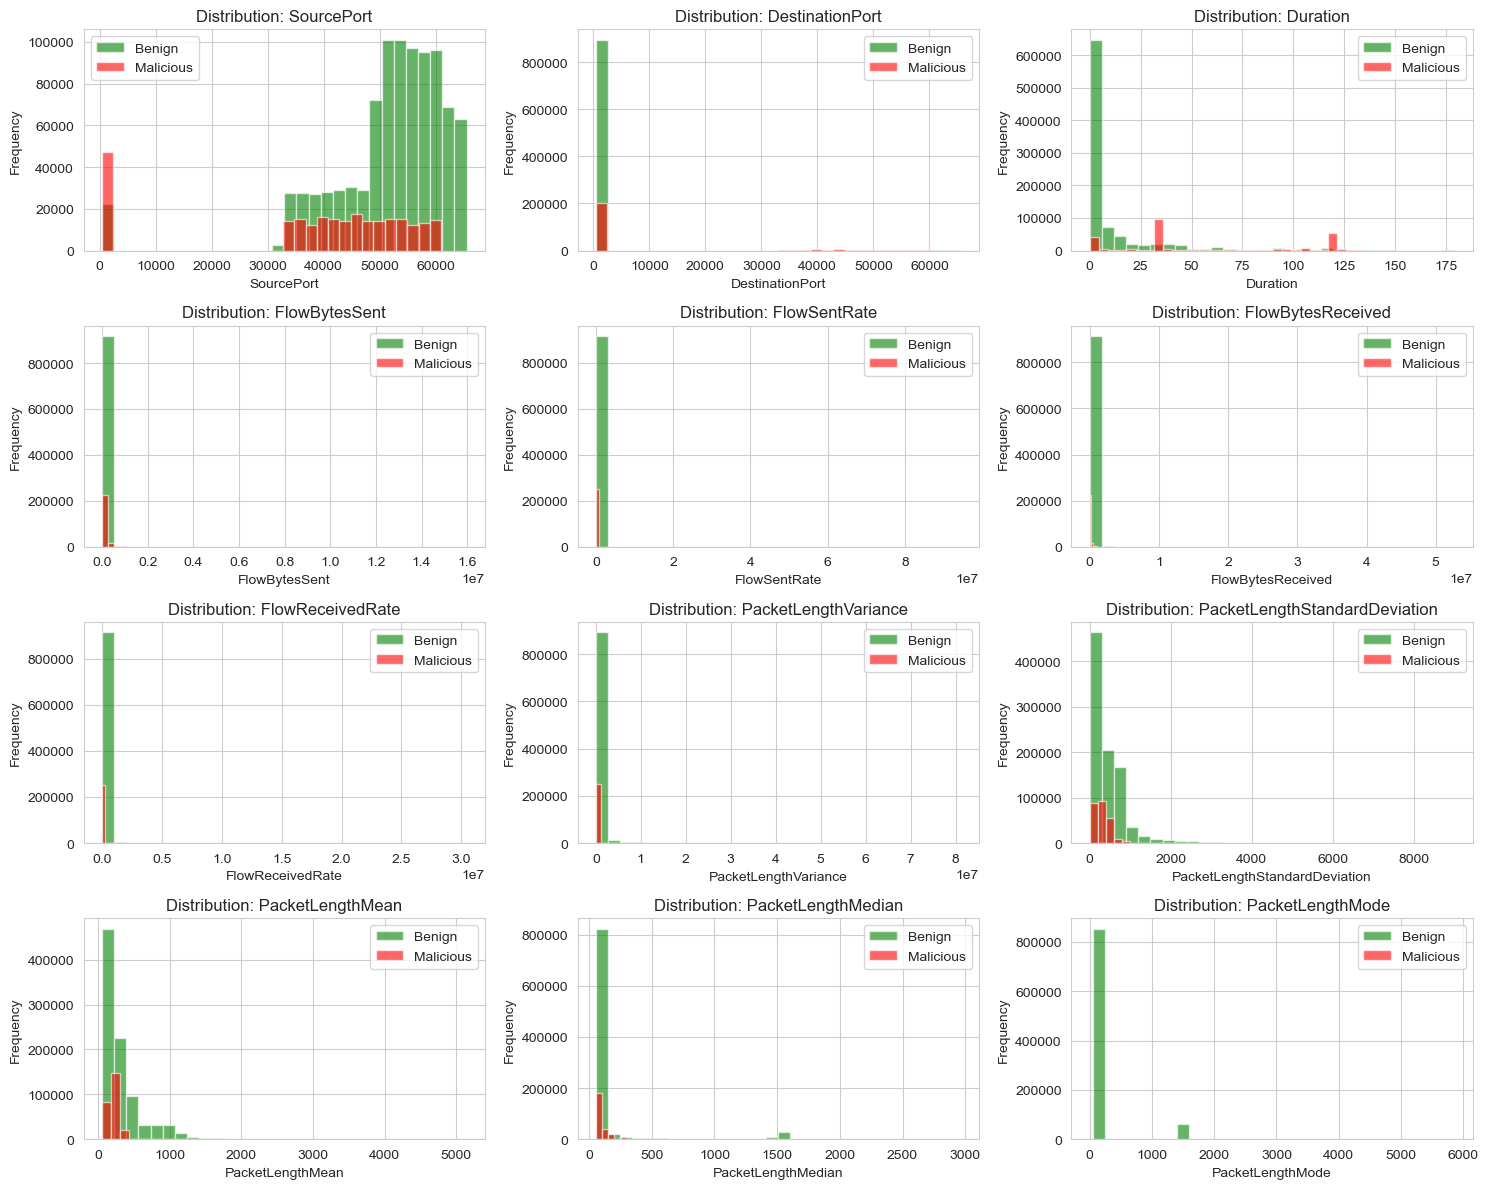

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Label' in numeric_cols:
    numeric_cols.remove('Label')

print(f'Total numeric features: {len(numeric_cols)}')

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:12]):
    benign = df[df['Label'] == 0][col]
    malicious = df[df['Label'] == 1][col]
    axes[idx].hist(benign, bins=30, alpha=0.6, label='Benign', color='green')
    axes[idx].hist(malicious, bins=30, alpha=0.6, label='Malicious', color='red')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution: {col}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('outputs/02_feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Statistical Summary by Class

In [7]:
stats_benign = df[df['Label'] == 0][numeric_cols].describe()
stats_malicious = df[df['Label'] == 1][numeric_cols].describe()

print('=== BENIGN STATISTICS ===')
print(stats_benign.iloc[:, :5])
print('\n=== MALICIOUS STATISTICS ===')
print(stats_malicious.iloc[:, :5])

=== BENIGN STATISTICS ===
          SourcePort  DestinationPort       Duration  FlowBytesSent  \
count  917300.000000    917300.000000  917300.000000   9.173000e+05   
mean    51649.443144      1765.275535      10.707437   2.851005e+03   
std     11358.308823      8436.843210      23.206000   3.575954e+04   
min       443.000000       443.000000       0.000000   0.000000e+00   
25%     48608.000000       443.000000       0.047400   1.470000e+02   
50%     53843.000000       443.000000       0.321000   1.195000e+03   
75%     58996.000000       443.000000       9.408085   2.240000e+03   
max     65534.000000     65534.000000     179.021144   1.597561e+07   

       FlowSentRate  
count  9.173000e+05  
mean   1.203408e+04  
std    2.815535e+05  
min   -1.000000e+00  
25%    2.325519e+02  
50%    2.037490e+03  
75%    5.115059e+03  
max    9.436036e+07  

=== MALICIOUS STATISTICS ===
       SourcePort  DestinationPort  Duration  FlowBytesSent  FlowSentRate
count         0.0              0

In [14]:
#dertermine the nAN values in each feature
from math import nan


#all nan values in the dataset

nan_counts = df[numeric_cols].isna().sum()
print('=== NAN VALUES PER FEATURE ===')
print(nan_counts)   

=== NAN VALUES PER FEATURE ===
SourcePort                                   0
DestinationPort                              0
Duration                                     0
FlowBytesSent                                0
FlowSentRate                                 0
FlowBytesReceived                            0
FlowReceivedRate                             0
PacketLengthVariance                         0
PacketLengthStandardDeviation                0
PacketLengthMean                             0
PacketLengthMedian                           0
PacketLengthMode                             0
PacketLengthSkewFromMedian                   0
PacketLengthSkewFromMode                     0
PacketLengthCoefficientofVariation           0
PacketTimeVariance                           0
PacketTimeStandardDeviation                  0
PacketTimeMean                               0
PacketTimeMedian                             0
PacketTimeMode                               0
PacketTimeSkewFromMedian     

In [16]:
null_mask = df['ResponseTimeTimeMedian'].isna()
print(df[null_mask]['Label'].value_counts())

Label
0    7745
1     283
Name: count, dtype: int64


In [17]:
df.shape

(1167269, 36)

## 5. Correlation Analysis

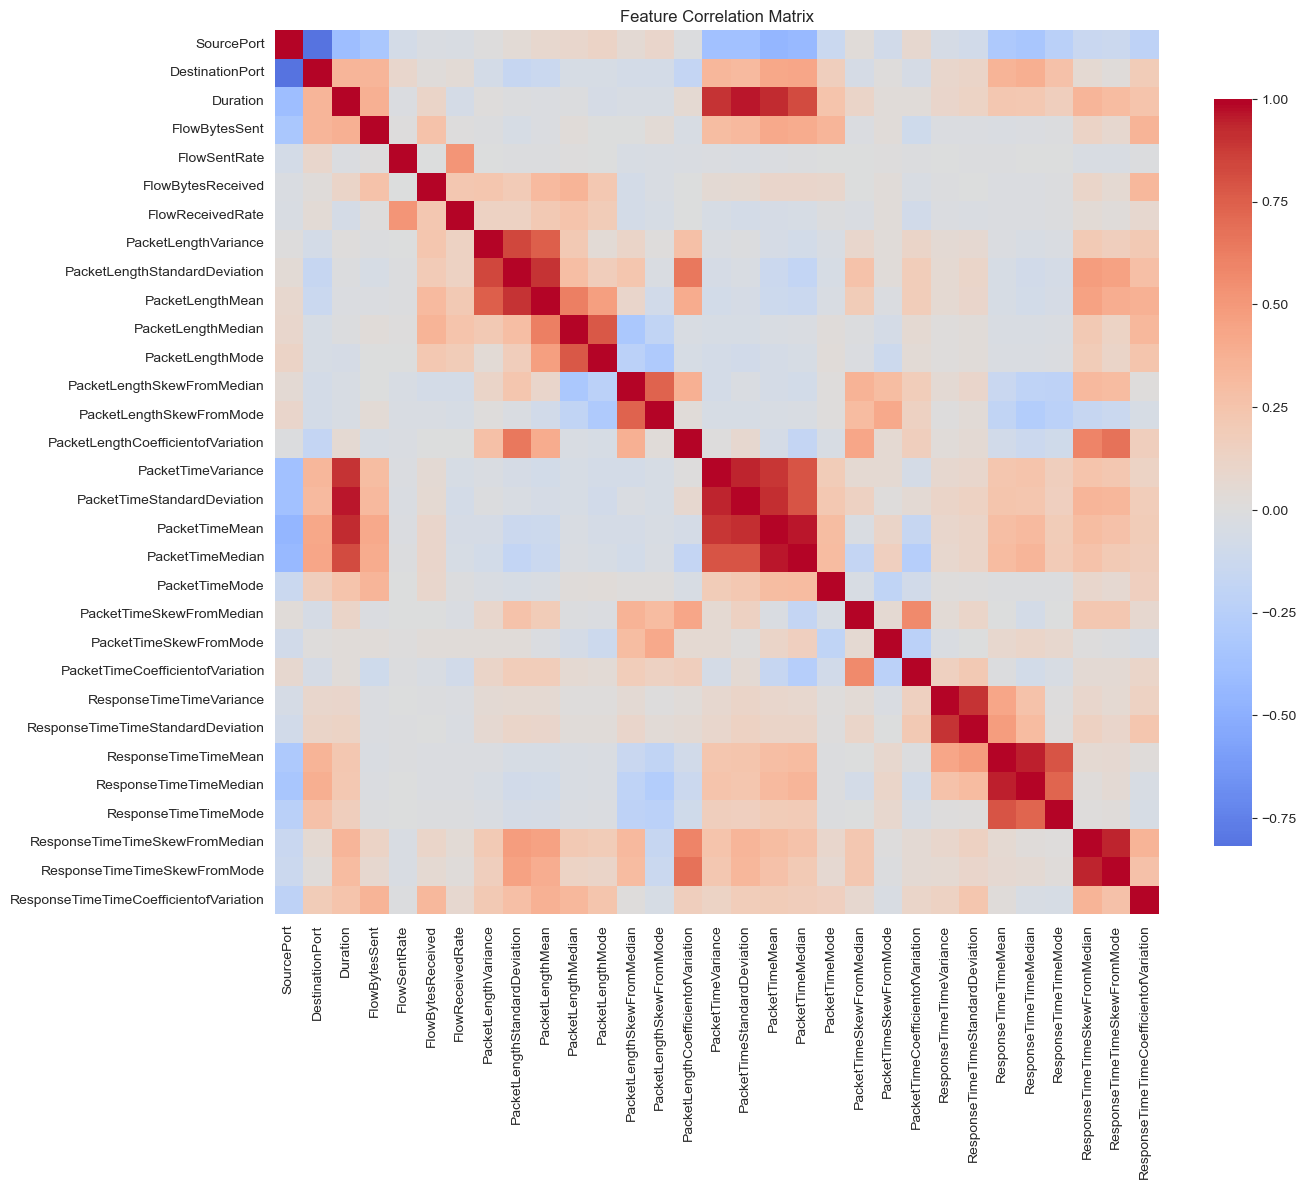


Highly correlated pairs (>0.9): 8
Duration & PacketTimeVariance: 0.90
Duration & PacketTimeStandardDeviation: 0.96
Duration & PacketTimeMean: 0.92
PacketTimeVariance & PacketTimeStandardDeviation: 0.94
PacketTimeStandardDeviation & PacketTimeMean: 0.91
PacketTimeMean & PacketTimeMedian: 0.96
ResponseTimeTimeMean & ResponseTimeTimeMedian: 0.94
ResponseTimeTimeSkewFromMedian & ResponseTimeTimeSkewFromMode: 0.94


In [15]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/03_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f'\nHighly correlated pairs (>0.9): {len(high_corr)}')
#print highly correlated pairs
for col1, col2, corr_value in high_corr:
    print(f'{col1} & {col2}: {corr_value:.2f}')

## 6. Outlier Detection

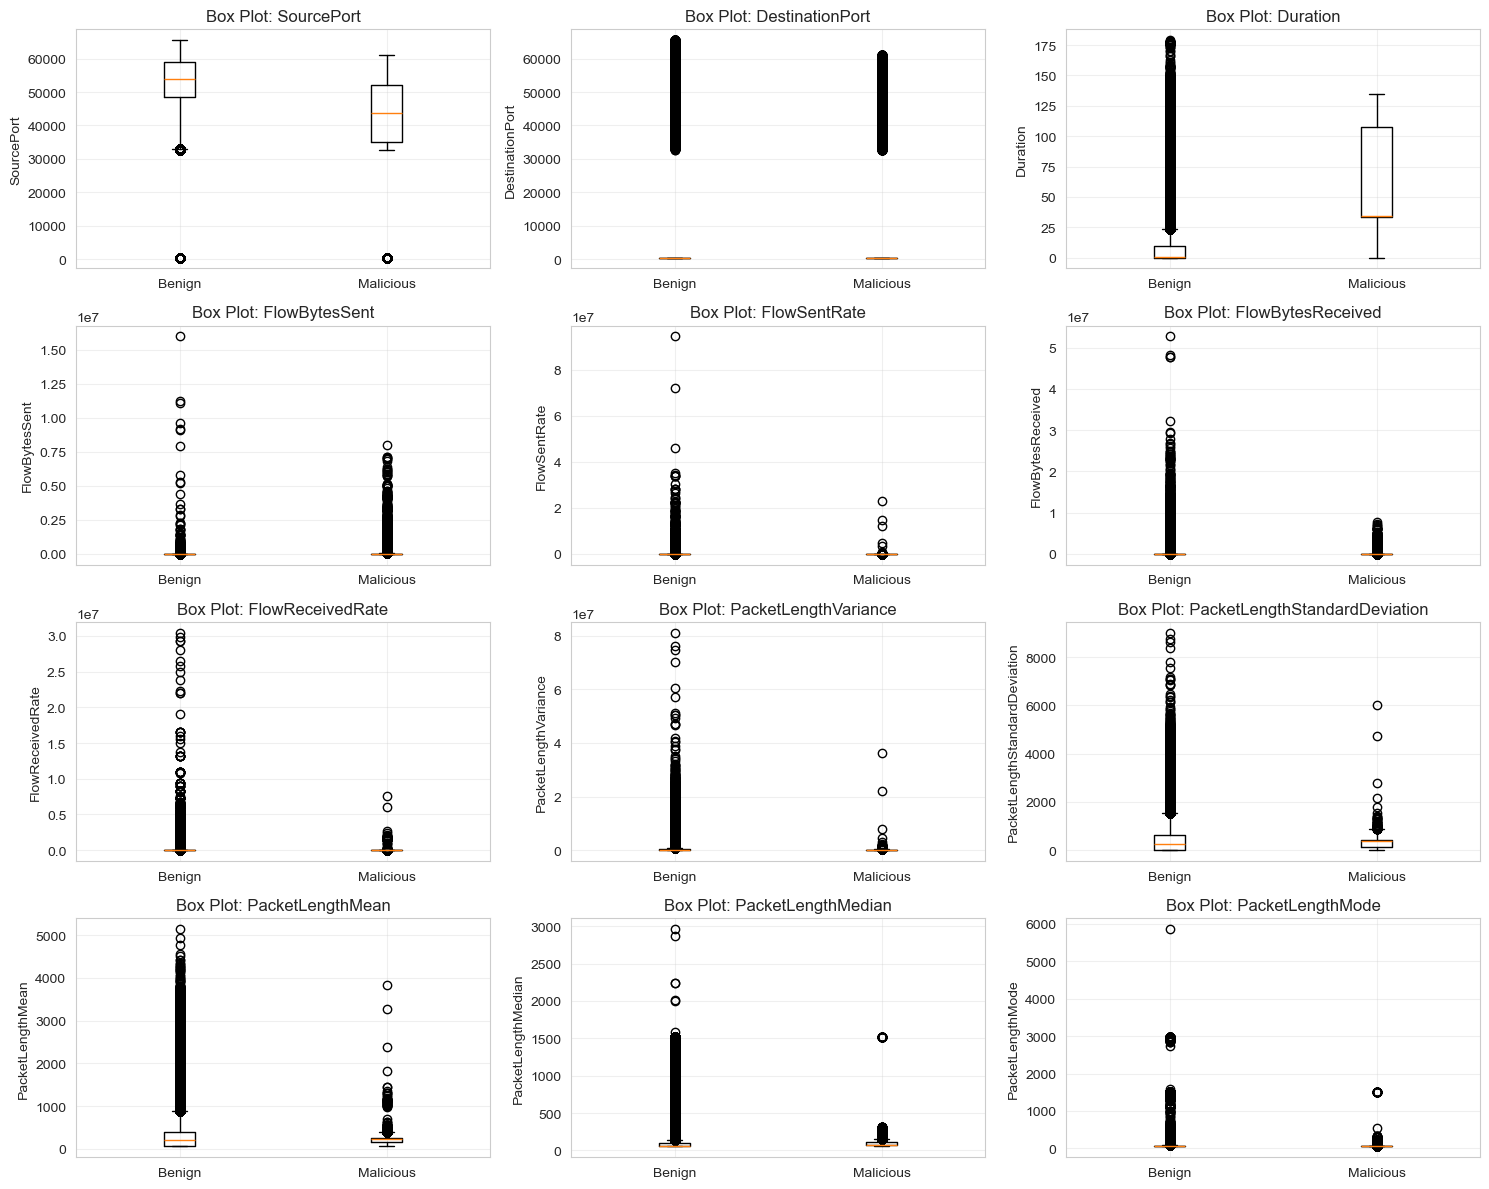

In [10]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:12]):
    data_to_plot = [df[df['Label'] == 0][col], df[df['Label'] == 1][col]]
    axes[idx].boxplot(data_to_plot, labels=['Benign', 'Malicious'])
    axes[idx].set_ylabel(col)
    axes[idx].set_title(f'Box Plot: {col}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/04_outlier_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Top Distinguishing Features

In [11]:
print(df.shape)
df_clean = df.dropna()
print(df_clean.shape)

(1167269, 36)
(1159241, 36)


=== TOP 10 DISTINGUISHING FEATURES ===
                               Feature  MI_Score
11                    PacketLengthMode  0.532429
10                  PacketLengthMedian  0.473501
3                        FlowBytesSent  0.404807
9                     PacketLengthMean  0.401522
8        PacketLengthStandardDeviation  0.396226
7                 PacketLengthVariance  0.396030
5                    FlowBytesReceived  0.351247
12          PacketLengthSkewFromMedian  0.345131
14  PacketLengthCoefficientofVariation  0.342319
13            PacketLengthSkewFromMode  0.324941


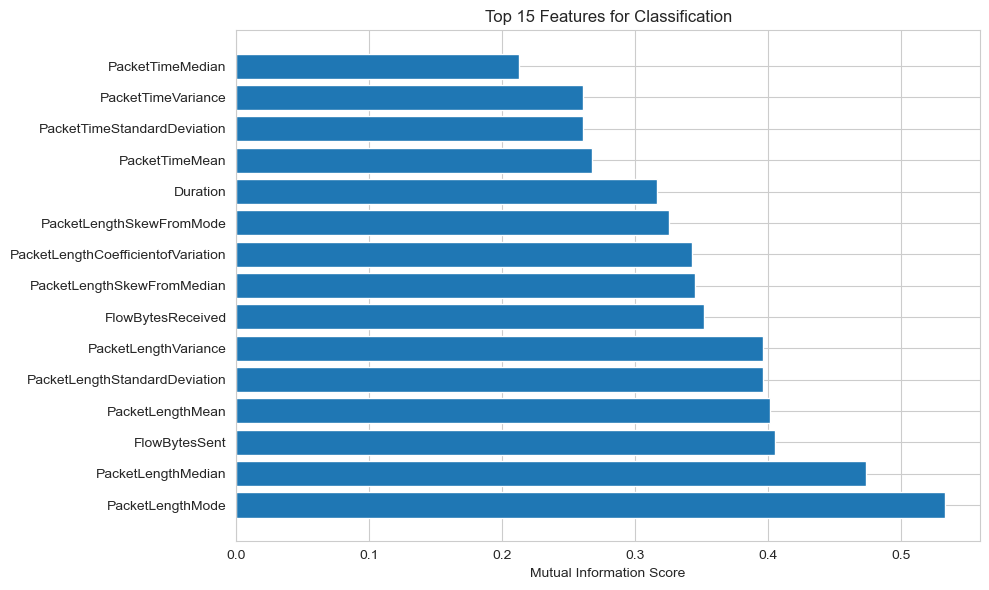

In [12]:
from sklearn.feature_selection import mutual_info_classif

# Drop NaN values before feature importance
df_clean = df.dropna()
X = df_clean[numeric_cols]
y = df_clean['Label']
mi_scores = mutual_info_classif(X, y, random_state=42)

feature_importance = pd.DataFrame({
    'Feature': numeric_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('=== TOP 10 DISTINGUISHING FEATURES ===')
print(feature_importance.head(10))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'][:15], feature_importance['MI_Score'][:15])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 15 Features for Classification')
plt.tight_layout()
plt.savefig('outputs/05_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. EDA Summary

In [13]:
print('=== EDA SUMMARY ===')
print(f'Total rows: {len(df):,}')
print(f'Benign: {(df["Label"] == 0).sum():,} ({(df["Label"] == 0).sum() / len(df) * 100:.1f}%)')
print(f'Malicious: {(df["Label"] == 1).sum():,} ({(df["Label"] == 1).sum() / len(df) * 100:.1f}%)')
print(f'Features: {len(numeric_cols)}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
if (df['Label'] == 1).sum() / len(df) < 0.1:
    print(f'⚠️  Class imbalance detected - recommend SMOTE for training')

=== EDA SUMMARY ===
Total rows: 1,167,269
Benign: 917,300 (78.6%)
Malicious: 249,969 (21.4%)
Features: 31
Missing values: 16056
Duplicates: 0
